In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

import os
os.getcwd()

# os.chdir("/home/jovyan/work/CN_A1_StructuralDescriptors")
os.chdir("/home/jovyan/work")
print(os.getcwd())
print(os.listdir())


/home/jovyan/work
['.git', 'A1-Log-Log-Histograms.pdf', 'activityA1', 'notebooks']


## Network 3

In [2]:
G_raw = nx.read_pajek('activityA1/net3.net')
G = nx.Graph(G_raw)

### Part 1

#### Nodes & Edges

In [3]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print(num_nodes)
print(num_edges)

5000
23508


#### Min, Max and Avg degree

In [4]:
degrees = [degree for node, degree in G.degree()]
min_deg = np.min(degrees)
max_deg = np.max(degrees)
avg_deg = np.mean(degrees)
print(f"Grado mínimo: {min_deg}")
print(f"Grado máximo: {max_deg}")
print(f"Grado promedio: {avg_deg:.2f}")

Grado mínimo: 3
Grado máximo: 732
Grado promedio: 9.40


#### Avg clustering coeficient

In [5]:
avg_clustering = nx.average_clustering(G)
print(f"Average clustering: {avg_clustering:.4f}")

transitivity = nx.transitivity(G)
print(f"Transitivity: {transitivity:.4f}")

Average clustering: 0.0862
Transitivity: 0.0214


#### Assortativity

In [6]:
assortativity = nx.degree_assortativity_coefficient(G)
print(f"Assortativity: {assortativity:.4f}")

Assortativity: -0.1339


#### Average path lenght & Diameter

In [7]:
if nx.is_connected(G):
    G_main = G
else:
    print("Net is disconected")
    largest_cc = max(nx.connected_components(G), key=len)
    G_main = G.subgraph(largest_cc)

avg_path = nx.average_shortest_path_length(G_main)
diameter = nx.diameter(G_main)
print(f"Average path lenght {avg_path:.4f}")
print(f"Diameter: {diameter}")


Average path lenght 3.0082
Diameter: 5


#### Degree distribution

The distribution for the network 3 in linear data its showing us that we have some few nodes that have all the conexions on the network, so a better way to represent the data is using a log-log distribution of the degrees

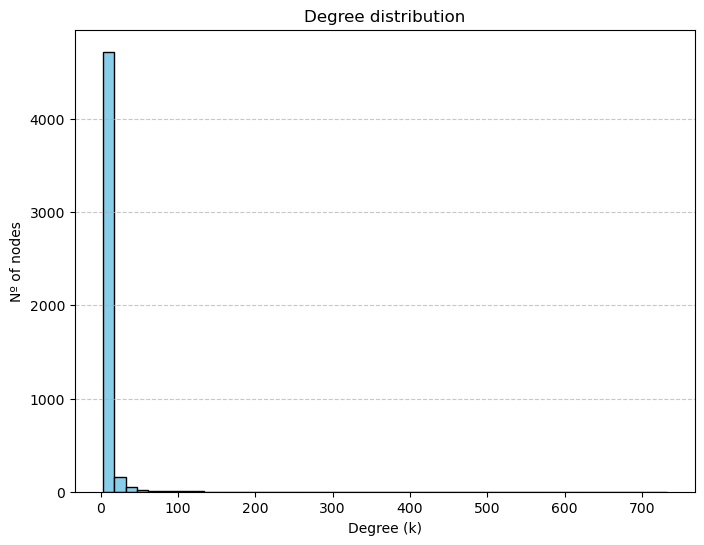

In [8]:
degrees = [degree for node, degree in G.degree()]

plt.figure(figsize=(8, 6))

plt.hist(degrees, bins=50, color='skyblue', edgecolor='black')

plt.title('Degree distribution')
plt.xlabel('Degree (k)')
plt.ylabel('Nº of nodes')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

As we can see in the log-log distribution we have a power law, this means that the network is based on a few hubs that suggests the network is a small world.

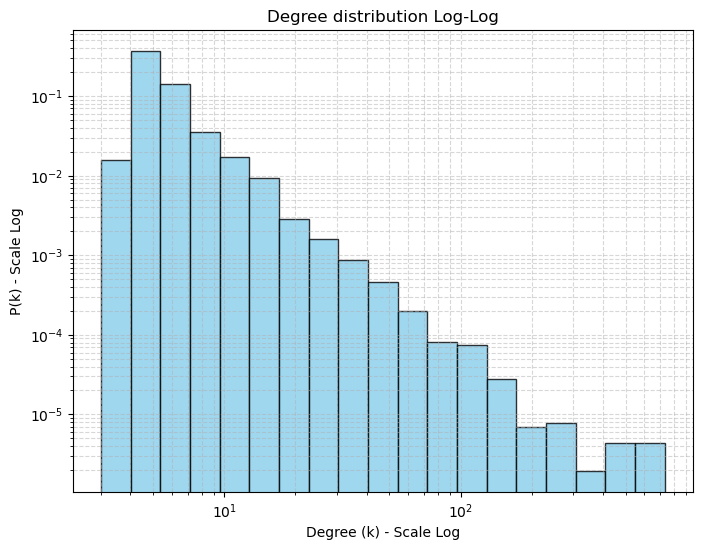

In [11]:
degrees = [degree for node, degree in G.degree()]

bins = np.logspace(np.log10(min(degrees)), np.log10(max(degrees)), 20)

plt.figure(figsize=(8, 6))

plt.hist(degrees, bins=bins, density=True, color='skyblue', edgecolor='black', alpha=0.8)

plt.xscale('log')
plt.yscale('log')

plt.title('Degree distribution Log-Log')
plt.xlabel('Degree (k) - Scale Log')
plt.ylabel('P(k) - Scale Log')
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

#### Degree centrality

In [12]:
def get_top_5(centrality_dict):
    return sorted(centrality_dict.items(), key=lambda item: item[1], reverse=True)[:5]

deg_cent = nx.degree_centrality(G)
print("\nTop 5 - Degree Centrality:")
for node, val in get_top_5(deg_cent):
    print(f"Node {node}: {val:.4f}")


Top 5 - Degree Centrality:
Node 5: 0.1464
Node 7: 0.1382
Node 2: 0.1252
Node 0: 0.1240
Node 6: 0.1110


#### Eigenvector centrality

In [13]:
try:
    eig_cent = nx.eigenvector_centrality(G, max_iter=1000)
    print("\nTop 5 - Eigenvector Centrality:")
    for node, val in get_top_5(eig_cent):
        print(f"Node {node}: {val:.4f}")
except nx.PowerIterationFailedConvergence:
    print("\nFailed on convergence")


Top 5 - Eigenvector Centrality:
Node 5: 0.2592
Node 7: 0.2417
Node 2: 0.2254
Node 0: 0.2254
Node 3: 0.2070


#### Betweeness centrality

In [14]:
bet_cent = nx.betweenness_centrality(G) 
print("\nTop 5 - Betweenness Centrality:")
for node, val in get_top_5(bet_cent):
    print(f"Node {node}: {val:.4f}")


Top 5 - Betweenness Centrality:
Node 5: 0.1378
Node 7: 0.1277
Node 0: 0.1113
Node 2: 0.1093
Node 6: 0.0943


In this case we have although the metrics show different conecpts we observed that we have a high correlation degree with the nodes 0,2,5 and 7 that show us the dominance in all the centralities. So as we checked before the network has a few hubs that are the core of the network.

### Part 2